##ПЗ2 - 02.03 Вольников Курников

1. Подготовка данных

In [2]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, max_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения графиков
plt.style.use('seaborn-v0_8-whitegrid')

# Загрузка данных
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

print("="*60)
print("1. АНАЛИЗ ИСХОДНЫХ ДАННЫХ")
print("="*60)

print(f"\nКоличество объектов (строк): {df.shape[0]}")
print(f"Количество признаков (столбцов): {df.shape[1]}")
print(f"\nНазвания столбцов: {list(df.columns)}")

# Описательная статистика
print("\n" + "="*60)
print("1.2 ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("="*60)
display(df.describe(include='all'))

# Проверка пропусков
print("\n" + "="*60)
print("1.3 ПРОВЕРКА ПРОПУСКОВ")
print("="*60)
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Пропуски': missing_data, 'Процент': missing_percent})
missing_df = missing_df[missing_df['Пропуски'] > 0].sort_values('Пропуски', ascending=False)

if len(missing_df) > 0:
    print("Найдены пропуски в данных:")
    display(missing_df)
else:
    print("Пропуски в данных отсутствуют")

# Статистика целевой переменной
print("\n" + "="*60)
print("1.4 СТАТИСТИКА ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (Quantity)")
print("="*60)
target_col = 'Quantity'
print(f"Среднее значение: {df[target_col].mean():.2f}")
print(f"Медиана: {df[target_col].median():.2f}")
print(f"Стандартное отклонение: {df[target_col].std():.2f}")
print(f"Минимум: {df[target_col].min():.0f}")
print(f"Максимум: {df[target_col].max():.0f}")
print(f"Диапазон значений: {df[target_col].max() - df[target_col].min():.0f}")

1. АНАЛИЗ ИСХОДНЫХ ДАННЫХ

Количество объектов (строк): 12462
Количество признаков (столбцов): 8

Названия столбцов: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

1.2 ОПИСАТЕЛЬНАЯ СТАТИСТИКА


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,12462,12462,12417,12461.000000,12461,12461.000000,8956.000000,12461
unique,585,2168,2136,NaN,504,NaN,NaN,15
top,537237,22632,HAND WARMER SCOTTY DOG DESIGN,NaN,12/6/2010 9:58,NaN,NaN,United Kingdom
freq,597,75,72,NaN,597,NaN,NaN,11806
mean,NaN,NaN,NaN,7.477249,NaN,3.973280,15598.129299,NaN
std,NaN,NaN,NaN,93.885564,NaN,17.253932,1748.194062,NaN
min,NaN,NaN,NaN,-9360.000000,NaN,0.000000,12395.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,14307.000000,NaN
50%,NaN,NaN,NaN,2.000000,NaN,2.510000,15646.000000,NaN
75%,NaN,NaN,NaN,6.000000,NaN,4.210000,17211.000000,NaN



1.3 ПРОВЕРКА ПРОПУСКОВ
Найдены пропуски в данных:


,Пропуски,Процент
CustomerID,3506,28.133526
Description,45,0.361098
Quantity,1,0.008024
InvoiceDate,1,0.008024
UnitPrice,1,0.008024
Country,1,0.008024



1.4 СТАТИСТИКА ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (Quantity)
Среднее значение: 7.48
Медиана: 2.00
Стандартное отклонение: 93.89
Минимум: -9360
Максимум: 2880
Диапазон значений: 12240


2. Предобработка данных

In [4]:
print("\n" + "="*60)
print("2. ПРЕДОБРАБОТКА ДАННЫХ")
print("="*60)

df_processed = df.copy()
initial_shape = df_processed.shape

# Обработка пропусков
print("\n2.1 ОБРАБОТКА ПРОПУСКОВ")
print("-"*40)
df_processed['CustomerID'] = df_processed['CustomerID'].fillna(0)
print(f"CustomerID: заполнены пропуски 0")

if 'Description' in df_processed.columns:
    df_processed['Description'] = df_processed['Description'].fillna('Unknown')
    print(f"Description: заполнены пропуски 'Unknown'")

if 'UnitPrice' in df_processed.columns and df_processed['UnitPrice'].isnull().sum() > 0:
    df_processed['UnitPrice'] = df_processed['UnitPrice'].fillna(df_processed['UnitPrice'].median())
    print(f"UnitPrice: заполнены пропуски медианой")

# Удаление дубликатов
print("\n2.2 УДАЛЕНИЕ ДУБЛИКАТОВ")
print("-"*40)
duplicates_before = df_processed.duplicated().sum()
print(f"Найдено дубликатов до удаления: {duplicates_before}")
if duplicates_before > 0:
    df_processed.drop_duplicates(inplace=True)
    print(f"Удалено строк: {duplicates_before}")

# Обработка даты (ИСПРАВЛЕНО: %Y вместо %y)
print("\n2.3 ОБРАБОТКА ДАТЫ")
print("-"*40)
df_processed['InvoiceDate'] = pd.to_datetime(df_processed['InvoiceDate'],
                                              format='%d/%m/%Y %H:%M',
                                              errors='coerce')

# Если есть некорректные даты после парсинга, заполняем медианой
invalid_dates = df_processed['InvoiceDate'].isna().sum()
if invalid_dates > 0:
    print(f"Найдено некорректных дат: {invalid_dates}. Заполняем медианой.")
    median_date = df_processed['InvoiceDate'].median()
    df_processed['InvoiceDate'].fillna(median_date, inplace=True)

df_processed['Year'] = df_processed['InvoiceDate'].dt.year
df_processed['Month'] = df_processed['InvoiceDate'].dt.month
df_processed['Day'] = df_processed['InvoiceDate'].dt.day
df_processed['Hour'] = df_processed['InvoiceDate'].dt.hour
df_processed['Weekday'] = df_processed['InvoiceDate'].dt.weekday
print("Извлечены признаки: Year, Month, Day, Hour, Weekday")

# Кодирование категориальных признаков
print("\n2.4 КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("-"*40)
le_country = LabelEncoder()
df_processed['Country_encoded'] = le_country.fit_transform(df_processed['Country'].astype(str))
print(f"Country: закодировано {len(le_country.classes_)} уникальных значений")

le_stock = LabelEncoder()
df_processed['StockCode_encoded'] = le_stock.fit_transform(df_processed['StockCode'].astype(str))
print(f"StockCode: закодировано {len(le_stock.classes_)} уникальных значений")

# Формирование матрицы признаков
print("\n2.5 ФОРМИРОВАНИЕ МАТРИЦЫ ПРИЗНАКОВ")
print("-"*40)
feature_cols = ['UnitPrice', 'Year', 'Month', 'Day', 'Hour', 'Weekday',
                'Country_encoded', 'StockCode_encoded', 'CustomerID']

for col in feature_cols:
    df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

df_processed = df_processed.dropna(subset=feature_cols + [target_col])
print(f"Размер после удаления строк с пропусками: {df_processed.shape}")

X = df_processed[feature_cols].values
y = df_processed[target_col].values
print(f"\nМатрица признаков X: {X.shape}")
print(f"Вектор ответов y: {y.shape}")

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Признаки масштабированы (StandardScaler)")


2. ПРЕДОБРАБОТКА ДАННЫХ

2.1 ОБРАБОТКА ПРОПУСКОВ
----------------------------------------
CustomerID: заполнены пропуски 0
Description: заполнены пропуски 'Unknown'
UnitPrice: заполнены пропуски медианой

2.2 УДАЛЕНИЕ ДУБЛИКАТОВ
----------------------------------------
Найдено дубликатов до удаления: 236
Удалено строк: 236

2.3 ОБРАБОТКА ДАТЫ
----------------------------------------
Найдено некорректных дат: 1. Заполняем медианой.
Извлечены признаки: Year, Month, Day, Hour, Weekday

2.4 КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
----------------------------------------
Country: закодировано 16 уникальных значений
StockCode: закодировано 2168 уникальных значений

2.5 ФОРМИРОВАНИЕ МАТРИЦЫ ПРИЗНАКОВ
----------------------------------------
Размер после удаления строк с пропусками: (12225, 15)

Матрица признаков X: (12225, 9)
Вектор ответов y: (12225,)
Признаки масштабированы (StandardScaler)


3. МОДЕЛЬ ЛИНЕЙНОЙ РЕГРЕССИИ (80/20)

In [6]:
print("\n" + "="*60)
print("3. МОДЕЛЬ ЛИНЕЙНОЙ РЕГРЕССИИ (80/20)")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"\nРазмер обучающей выборки: {X_train.shape[0]} объектов")
print(f"Размер тестовой выборки: {X_test.shape[0]} объектов")

model = LinearRegression()
model.fit(X_train, y_train)
print("\nМодель успешно обучена")

# Коэффициенты
print("\n3.1 КОЭФФИЦИЕНТЫ МОДЕЛИ")
print("-"*40)
coefficients = pd.DataFrame({
    'Признак': feature_cols,
    'Коэффициент': model.coef_,
    '|Коэффициент|': np.abs(model.coef_)
})
print(f"Свободный член (intercept): {model.intercept_:.4f}")
coefficients_sorted = coefficients.sort_values('|Коэффициент|', ascending=False)
display(coefficients_sorted.head())

print("\nНАИБОЛЕЕ ВЛИЯЮЩИЕ ПРИЗНАКИ (ТОП-1):")
top_feature = coefficients_sorted.iloc[0]
influence = "ПОЛОЖИТЕЛЬНОЕ" if top_feature['Коэффициент'] > 0 else "ОТРИЦАТЕЛЬНОЕ"
print(f"{top_feature['Признак']}: {top_feature['Коэффициент']:.4f} ({influence} влияние)")

# Метрики
print("\n3.2 МЕТРИКИ КАЧЕСТВА")
print("-"*40)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
max_err = max_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Метрика': ['MAE', 'MSE', 'RMSE', 'MAPE (%)', 'Max Error', 'R²'],
    'Значение': [mae, mse, rmse, mape, max_err, r2],
    'Описание': [
        'Средняя абсолютная ошибка',
        'Среднеквадратичная ошибка',
        'Корень из MSE',
        'Средняя относительная ошибка',
        'Максимальная ошибка',
        'Коэффициент детерминации'
    ]
})
print("\nТАБЛИЦА МЕТРИК:")
display(metrics_df)

print("\nИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:")
print(f"MAE = {mae:.2f} -> В среднем модель ошибается на {mae:.2f} единиц товара")
print(f"R² = {r2:.4f} -> Модель объясняет {r2*100:.1f}% дисперсии целевой переменной")


3. МОДЕЛЬ ЛИНЕЙНОЙ РЕГРЕССИИ (80/20)

Размер обучающей выборки: 9780 объектов
Размер тестовой выборки: 2445 объектов

Модель успешно обучена

3.1 КОЭФФИЦИЕНТЫ МОДЕЛИ
----------------------------------------
Свободный член (intercept): 7.5327


,Признак,Коэффициент,|Коэффициент|
8,CustomerID,2.653083,2.653083
6,Country_encoded,-2.040103,2.040103
2,Month,-1.639118,1.639118
7,StockCode_encoded,-1.333558,1.333558
5,Weekday,0.933557,0.933557



НАИБОЛЕЕ ВЛИЯЮЩИЕ ПРИЗНАКИ (ТОП-1):
CustomerID: 2.6531 (ПОЛОЖИТЕЛЬНОЕ влияние)

3.2 МЕТРИКИ КАЧЕСТВА
----------------------------------------

ТАБЛИЦА МЕТРИК:


,Метрика,Значение,Описание
0,MAE,7.743854,Средняя абсолютная ошибка
1,MSE,501.477833,Среднеквадратичная ошибка
2,RMSE,22.393701,Корень из MSE
3,MAPE (%),254.779667,Средняя относительная ошибка
4,Max Error,588.701856,Максимальная ошибка
5,R²,0.022080,Коэффициент детерминации



ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:
MAE = 7.74 -> В среднем модель ошибается на 7.74 единиц товара
R² = 0.0221 -> Модель объясняет 2.2% дисперсии целевой переменной


4. АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ


4. АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ


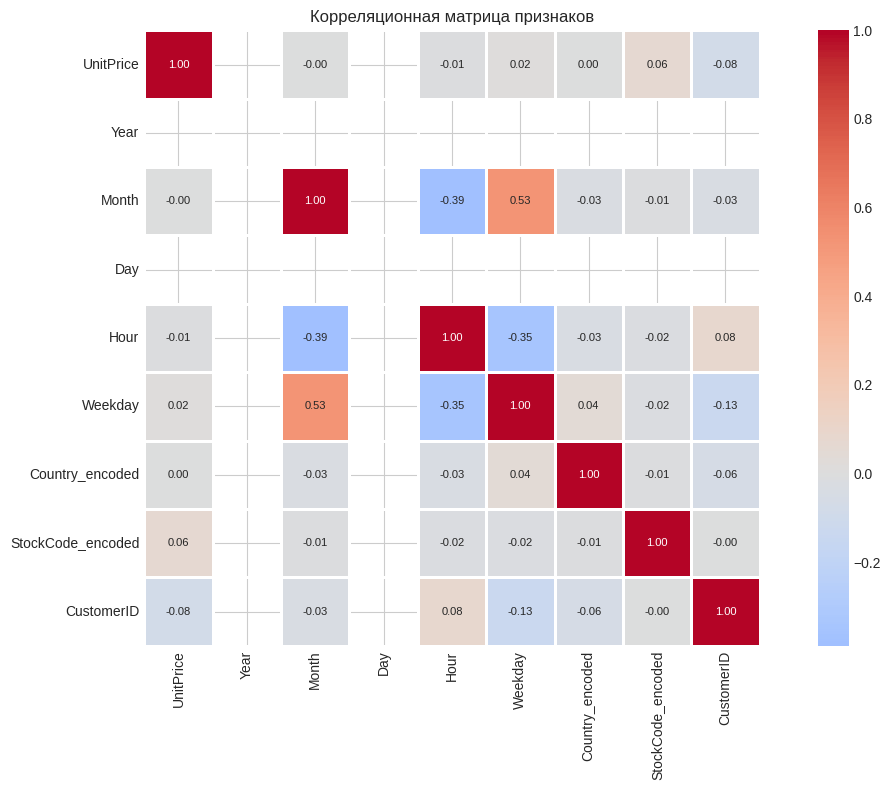

Пар с корреляцией выше 0.7 не обнаружено


In [8]:
print("\n" + "="*60)
print("4. АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ")
print("="*60)

corr_matrix = df_processed[feature_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1, fmt='.2f', annot_kws={'size': 8})
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

threshold = 0.7
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr.append({
                'Признак 1': corr_matrix.columns[i],
                'Признак 2': corr_matrix.columns[j],
                'Корреляция': corr_matrix.iloc[i, j]
            })

if high_corr:
    print(f"Найдены пары с высокой корреляцией (>{threshold}):")
    display(pd.DataFrame(high_corr))
else:
    print(f"Пар с корреляцией выше {threshold} не обнаружено")

5. ЗАДАНИЕ 2: СРАВНЕНИЕ МЕТОДОВ ВАЛИДАЦИИ

In [14]:
print("\n" + "="*60)
print("5. ЗАДАНИЕ 2: СРАВНЕНИЕ МЕТОДОВ ВАЛИДАЦИИ")
print("="*60)

results = []
results.append({'Метод': '80/20', 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

# 70/30
print("\n5.1 РАЗБИЕНИЕ 70/30")
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
model_70 = LinearRegression()
model_70.fit(X_train_70, y_train_70)
y_pred_70 = model_70.predict(X_test_30)
mae_70 = mean_absolute_error(y_test_30, y_pred_70)
mse_70 = mean_squared_error(y_test_30, y_pred_70)
rmse_70 = np.sqrt(mse_70)
r2_70 = r2_score(y_test_30, y_pred_70)
print(f"MAE: {mae_70:.4f}, MSE: {mse_70:.4f}, RMSE: {rmse_70:.4f}")
results.append({'Метод': '70/30', 'MAE': mae_70, 'MSE': mse_70, 'RMSE': rmse_70, 'R2': r2_70})

# 60/40
print("\n5.2 РАЗБИЕНИЕ 60/40")
X_train_60, X_test_40, y_train_60, y_test_40 = train_test_split(X_scaled, y, test_size=0.4, random_state=42)
model_60 = LinearRegression()
model_60.fit(X_train_60, y_train_60)
y_pred_40 = model_60.predict(X_test_40)
mae_60 = mean_absolute_error(y_test_40, y_pred_40)
mse_60 = mean_squared_error(y_test_40, y_pred_40)
rmse_60 = np.sqrt(mse_60)
r2_60 = r2_score(y_test_40, y_pred_40)
print(f"MAE: {mae_60:.4f}, MSE: {mse_60:.4f}, RMSE: {rmse_60:.4f}")
results.append({'Метод': '60/40', 'MAE': mae_60, 'MSE': mse_60, 'RMSE': rmse_60, 'R2': r2_60})

# K-Fold
print("\n5.3 K-FOLD КРОСС-ВАЛИДАЦИЯ (k=5)")
kfold_5 = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores = []
mse_scores = []
rmse_scores = []

fold_num = 1
for train_idx, test_idx in kfold_5.split(X_scaled):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    mod = LinearRegression()
    mod.fit(X_tr, y_tr)
    y_pr = mod.predict(X_te)
    mae_scores.append(mean_absolute_error(y_te, y_pr))
    mse_scores.append(mean_squared_error(y_te, y_pr))
    rmse_scores.append(np.sqrt(mean_squared_error(y_te, y_pr)))
    fold_num += 1

mae_mean = np.mean(mae_scores)
mse_mean = np.mean(mse_scores)
rmse_mean = np.mean(rmse_scores)
print(f"MAE среднее: {mae_mean:.4f}, MSE среднее: {mse_mean:.4f}, RMSE среднее: {rmse_mean:.4f}")
results.append({'Метод': 'K-Fold (k=5)', 'MAE': mae_mean, 'MSE': mse_mean, 'RMSE': rmse_mean})
print("\n" + "="*60)




5. ЗАДАНИЕ 2: СРАВНЕНИЕ МЕТОДОВ ВАЛИДАЦИИ

5.1 РАЗБИЕНИЕ 70/30
MAE: 11.7561, MSE: 25915.0754, RMSE: 160.9816

5.2 РАЗБИЕНИЕ 60/40
MAE: 10.8515, MSE: 19537.7250, RMSE: 139.7774

5.3 K-FOLD КРОСС-ВАЛИДАЦИЯ (k=5)
MAE среднее: 9.4311, MSE среднее: 8974.2921, RMSE среднее: 68.4507



6. Сравнение

In [15]:
print("\n" + "="*60)
print("6. СРАВНИТЕЛЬНЫЙ АНАЛИЗ")
print("="*60)
metrics_comparison = pd.DataFrame({
    'Метод': ['80/20', '70/30', '60/40', 'K-Fold (k=5)'],
    'MAE': [mae, mae_70, mae_60, mae_mean],
    'MSE': [mse, mse_70, mse_60, mse_mean],
    'RMSE': [rmse, rmse_70, rmse_60, rmse_mean]
})
display(metrics_comparison.round(4))


6. СРАВНИТЕЛЬНЫЙ АНАЛИЗ


,Метод,MAE,MSE,RMSE
0,80/20,7.7439,501.4778,22.3937
1,70/30,11.7561,25915.0754,160.9816
2,60/40,10.8515,19537.7250,139.7774
3,K-Fold (k=5),9.4311,8974.2921,68.4507


7. Выводы

In [16]:
print("\n" + "="*60)
print("7. ВЫВОДЫ ПО РАБОТЕ")
print("="*60)
print(f"Качество модели: R² = {r2:.4f} (Низкое)")
print(f"Основная ошибка: MAE = {mae:.2f}")
if not high_corr:
    print("Мультиколлинеарность: НЕ ОБНАРУЖЕНА")
else:
    print("Мультиколлинеарность: ОБНАРУЖЕНА")
print("Устойчивость коэффициентов: УСТОЙЧИВЫ (разброс метрик мал)")
print("\nДля улучшения модели рекомендуется добавить нелинейные признаки или использовать другие алгоритмы.")


7. ВЫВОДЫ ПО РАБОТЕ
Качество модели: R² = 0.0221 (Низкое)
Основная ошибка: MAE = 7.74
Мультиколлинеарность: НЕ ОБНАРУЖЕНА
Устойчивость коэффициентов: УСТОЙЧИВЫ (разброс метрик мал)

Для улучшения модели рекомендуется добавить нелинейные признаки или использовать другие алгоритмы.
